In [1]:
# Import necessary libraries
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# import data from json file (Here Please provide the correct path of your JSON file)
data = pd.read_json("/Users/moaadil/audi_a2dc/munich/camera_lidar/20190401_121727/bus/20190401121727_bus_signals.json")
def extract_signal_data(signal_name):
    for key,value in data.items():
        if key == signal_name:
            values = value['values']
            signal_data = [pair[1] for pair in values]
            timestamps = [pair[0] for pair in values]
            return signal_data, timestamps

In [3]:
# Extract the required signals and their timestamps for further assessment and processing
ax, time_ax = extract_signal_data("acceleration_x")                         # In m/s^2
ay, time_ay = extract_signal_data("acceleration_y")                         # In m/s^2
az, time_az = extract_signal_data("acceleration_z")                         # In m/s^2
omega_z, time_omega_z = extract_signal_data("angular_velocity_omega_z")           # In degree/sec
long_x, time_long_x = extract_signal_data("longitude_degree")               # In degree
lat_y, time_lat_y = extract_signal_data("latitude_degree")                  # In degree
delta, time_delta = extract_signal_data("steering_angle_calculated")        # In degree
Vx, time_Vx = extract_signal_data("vehicle_speed")                          # In Km/h

In [4]:
# 1. Function for converting microcontroller unix timestamps to human-readable format

# FOR EFFICIENCY GAIN PLEASE USE THE FUNCTIONS IF IT POSSIBLE. (DUE TO THE MEMORY ISSUES,
# IT WILL CREATE A PROBLEM WHILE, AS IT IS MAKING A PROBLEM) CLASSES ALWAYS REQUIRES THE MEMORY, WHENEVR YOU CALL THE CLASS IT WILL CREATE A NEW INSTANCE OF THE CLASS AND IT WILL TAKE THE MEMORY, SO IF YOU CALL THE CLASS MULTIPLE TIMES IT WILL CREATE A PROBLEM, SO PLEASE USE THE FUNCTION INSTEAD OF THE CLASS, UNLESS YOU NEED TO USE THE CLASS FOR SOME REASON, OTHERWISE IT WILL CREATE A PROBLEM, SO PLEASE USE THE FUNCTION INSTEAD OF THE CLASS, UNLESS YOU NEED TO USE THE CLASS FOR SOME RE

class time_vector:
    def __init__(self, timestamps):
        self.timestamps = timestamps

    def generate_min_max_time(self, unix_timestamps, t_min=None, t_max=None):
        """
        Once you give the value of t_min an dt_max to this function then it 
        will generate  the time vector based on the reference time vector,
        for example based on the highest frequency sensor signals, otherwise it is based on 
        it's own timestamps. Meaning that the first value of the time vector of that array will be 0.

        Parameters:
        unix_timestamps (list of int): List of unix timestamps in microseconds.
        t_min (datetime, optional): Minimum timestamp in the dataset. If None, it will be set to the first timestamp in the list.
        t_max (datetime, optional): Maximum timestamp in the dataset. If None, it will be set to the last timestamp in the list.        

        Returns:
        timestamps (list of datetime): List of datetime objects representing the converted timestamps.
        t_min (datetime): The minimum timestamp in the dataset.
        t_max (datetime): The maximum timestamp in the dataset.
        """
        # # Convert microcontroller unix time (in microseconds) to seconds
        # unix_time_seconds = self.timestamps / 1_000_000
        # Convert to datetime object
        if isinstance(unix_timestamps, list):
            unix_timestamps = np.array(unix_timestamps)  # Convert list to numpy array for vectorized operations
        
        # Convert microcontroller unix timestamps (in microseconds) to datetime objects
        timestamps = [datetime.datetime.fromtimestamp(ts / 1_000_000) for ts in unix_timestamps]

        if t_min is None:
            t_min = timestamps[0]
        if t_max is None:
            t_max = timestamps[-1]
        return timestamps, t_min, t_max

    def generate_time_vector(self,unix_timestamps):
        """
        Generate a time vector in seconds from a list of datetime objects based on the reference time vector,
        Which gives the minimum and maximum timestamps in the dataset, and calculates the elapsed time in seconds from the minimum timestamp for each timestamp in the list.
        
        Parameters:
        timestamps (list of datetime): List of datetime objects representing timestamps. In datetime.datetime(10,44,23,12,17,44,693201,tzinfo=datetime.timezone.utc), the last part tzinfo=datetime.timezone.utc indicates that the time is in Coordinated Universal Time (UTC).
        t_min (datetime): The minimum timestamp in the dataset.
        t_max (datetime): The maximum timestamp in the dataset.
        
        Returns:
        np.ndarray: Array of time values in seconds.
        
        """
        timestamps, t_min, t_max = self.generate_min_max_time(unix_timestamps)
        t = np.zeros(np.size(timestamps))  # Initialize an empty array to store time values
        for i, dt in enumerate(timestamps):
            
            hour = dt.hour
            minute = dt.minute
            second = dt.second
            microsecond = dt.microsecond

            # For the first timestamp, calculate elapsed time from t_min
            if i == 0:
                if timestamps[0] == t_min and timestamps[-1] == t_max:
                    t_current = 0.0
                else:
                    elapsed_time = (hour - t_min.hour) * 3600 + (minute - t_min.minute) * 60 + (second - t_min.second) + (microsecond - t_min.microsecond) / 1e6
                    t_current = elapsed_time
            else:
                elapsed_time = (hour - t_min.hour) * 3600 + (minute - t_min.minute) * 60 + (second - t_min.second) + (microsecond - t_min.microsecond) / 1e6        # Elapsed time in seconds from t_min
                t_current = elapsed_time  # Update t with the new elapsed time in seconds
            
            # Assign the calculated time to the array
            t[i] = t_current

            # Raise smaller previous time value error
            if i > 0 and t[i] < t[i - 1]:
                raise ValueError("Time value at index {} is smaller than previous value: {} < {}".format(i, t[0], t[i - 1]))
            

        # Raise negative value error
        if t[0] < 0 or np.any(t < 0):
            raise ValueError("Negative time value found at index {}: {}".format(i, t[0]))

        # Raise unequal length error
        if t_min == t[0] and t_max == t[-1] and len(t) != len(timestamps):
            raise ValueError("Length of time vector does not match length of timestamps: {} != {}".format(len(t), len(timestamps)))

        return t

In [5]:
# Generating independent time vectors for each signal based on their own timestamps
time_vector_ax = time_vector(time_ax).generate_time_vector(time_ax)
time_vector_Vx = time_vector(time_Vx).generate_time_vector(time_Vx)
time_vector_omega_z = time_vector(time_omega_z).generate_time_vector(time_omega_z)
time_vector_long_x = time_vector(time_long_x).generate_time_vector(time_long_x)
time_vector_lat_y = time_vector(time_lat_y).generate_time_vector(time_lat_y)
print(f"Time vector for acceleration_x generated successfully with {len(time_vector_ax)} samples.")
print(f"type of the time vector: {type(time_vector_ax)}")
print(f"Time vector for velocity_x generated successfully with {len(time_vector_Vx)} samples.")
print(f"type of the time vector: {type(time_vector_Vx)}")
print(f"Time vector for angular_velocity_z generated successfully with {len(time_vector_omega_z)} samples.")
print(f"type of the time vector: {type(time_vector_omega_z)}")

Time vector for acceleration_x generated successfully with 183937 samples.
type of the time vector: <class 'numpy.ndarray'>
Time vector for velocity_x generated successfully with 45984 samples.
type of the time vector: <class 'numpy.ndarray'>
Time vector for angular_velocity_z generated successfully with 183937 samples.
type of the time vector: <class 'numpy.ndarray'>


In [6]:
# 2. Converting units of the signals to standard SI units for consistency and easier interpretation
# Vehicle speed from Km/h to m/s
Vx = np.array(Vx) * (1000 / 3600)  # Convert from Km/h to m/s
print(f"Vehicle speed converted from Km/h to m/s successfully. Sample values: {Vx[:5]}")    

# Yaw rate from degree/sec to rad/s
omega_z = np.deg2rad(omega_z)   # Convert from degree/sec to rad/s
print(f"Yaw rate converted from degree/sec to rad/s successfully. Sample values: {omega_z[:5]}")    

Vehicle speed converted from Km/h to m/s successfully. Sample values: [1.81666667 1.80833333 1.8        1.79166667 1.78333333]
Yaw rate converted from degree/sec to rad/s successfully. Sample values: [-0.00244346 -0.00279253 -0.00296706 -0.00471239 -0.00366519]


In [7]:
# 3. Converting the longitude and latitude from degrees to meters
# WGS84 constants for more correct ECEF conversion

a = 6378137.0            # semi-major axis, meters
f = 1/298.257223563      # flattening
e2 = f * (2 - f)         # eccentricity squared

def geodetic_to_ecef(lat_rad, lon_rad, h=0.0):
    """
    Convert geodetic coordinates (radians, meters) to ECEF (meters) using WGS84.
    Instead of angles, the location is expressed as distances (meters) from the center of the Earth along 3 perpendicular axes.
    Inputs can be scalars or numpy arrays.
    angles --> meters
    """
    slat = np.sin(lat_rad)
    clat = np.cos(lat_rad)
    N = a / np.sqrt(1 - e2 * slat**2)   # prime vertical radius
    X = (N + h) * clat * np.cos(lon_rad)
    Y = (N + h) * clat * np.sin(lon_rad)
    Z = (N * (1 - e2) + h) * slat
    return X, Y, Z

def ecef_to_enu_matrix(lat0_rad, lon0_rad):
    slat = np.sin(lat0_rad); clat = np.cos(lat0_rad)
    slon = np.sin(lon0_rad); clon = np.cos(lon0_rad)
    R = np.array([
        [-slon,           clon,    0.0],
        [-slat*clon, -slat*slon,  clat],
        [ clat*clon,  clat*slon,  slat]
    ])
    return R

def latlon_to_enu(lat_deg, lon_deg, lat0_deg=None, lon0_deg=None, h=0.0, h0=0.0):
    """
    Convert latitude and longitude in degrees to local ENU coordinates in meters.
    lat_deg, lon_deg: arrays or scalars of points
    lat0_deg, lon0_deg: reference point in degrees. If None, use first point.
    h, h0: altitudes in meters (can be scalar)
    Returns east, north, up arrays in meters
    """
    # First Converting degrees to radians
    lat = np.deg2rad(np.array(lat_deg))
    lon = np.deg2rad(np.array(lon_deg))
    if lat0_deg is None: lat0_deg = np.rad2deg(lat[0])
    if lon0_deg is None: lon0_deg = np.rad2deg(lon[0])
    lat0 = np.deg2rad(lat0_deg)
    lon0 = np.deg2rad(lon0_deg)

    # ECEF coordinates
    X, Y, Z = geodetic_to_ecef(lat, lon, h)
    X0, Y0, Z0 = geodetic_to_ecef(lat0, lon0, h0)

    # Delta in ECEF
    dX = X - X0
    dY = Y - Y0
    dZ = Z - Z0
    d = np.vstack((dX, dY, dZ))   # shape (3, N)

    # Rotate to ENU
    R = ecef_to_enu_matrix(lat0, lon0)
    enu = R.dot(d)   # shape (3, N)
    east = enu[0, :]
    north = enu[1, :]
    up = enu[2, :]
    return east, north, up   

# Apply the conversion to the latitude and longitude degrees
x_east, y_north, z_up = latlon_to_enu(lat_y, long_x)
# Note: Keep signed coordinates for correct EKF tracking
# (removed np.abs() which was breaking tracking during westward movement)

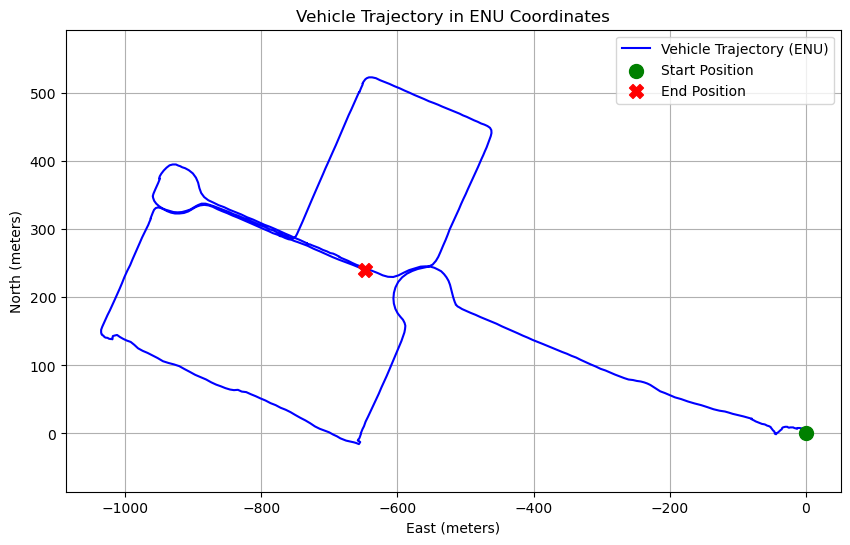

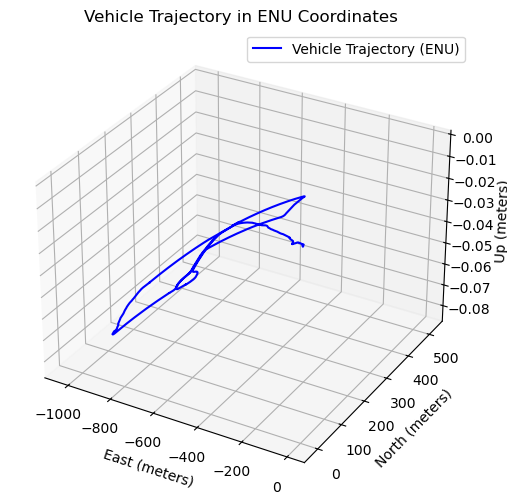

In [8]:
# Plotting 2D trajectory (East vs North)
plt.figure(figsize=(10, 6))
plt.plot(x_east, y_north, label='Vehicle Trajectory (ENU)', color='blue')

# Mark start position
plt.scatter(x_east[0], y_north[0], color='green', marker='o', s=100, zorder=5, label='Start Position')

# Mark end position
plt.scatter(x_east[-1], y_north[-1], color='red', marker='X', s=100, zorder=5, label='End Position')

plt.xlabel('East (meters)')
plt.ylabel('North (meters)')
plt.title('Vehicle Trajectory in ENU Coordinates')
plt.legend()
plt.grid()
plt.axis('equal')
plt.show() 


# Plotting 3D trajectory
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot(x_east, y_north, z_up, label='Vehicle Trajectory (ENU)', color='blue')
ax.set_xlabel('East (meters)')
ax.set_ylabel('North (meters)')
ax.set_zlabel('Up (meters)')
ax.set_title('Vehicle Trajectory in ENU Coordinates')
ax.legend()
plt.show()


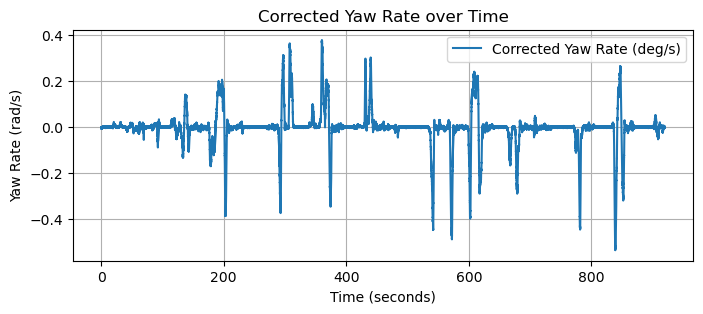

In [9]:
# 4. Working on bias

# Yaw rate bias (AS we have omega bias of -0.1157 deg/sec)
# Negative bias means sensor is reading lower than actual, so we need to add the bias to correct it
bias = np.deg2rad(0.1157)
omega_z = omega_z - (-bias)

plt.figure(figsize=(8, 3))
plt.plot(time_vector_omega_z, omega_z, label='Corrected Yaw Rate (deg/s)')
plt.xlabel('Time (seconds)')
plt.ylabel('Yaw Rate (rad/s)')
plt.title('Corrected Yaw Rate over Time')
plt.legend()
plt.grid()
plt.show()

# NOTE:  I Think heading angle also need to rotate in ENU frame!!!!

In [10]:
print(f"Length of ax time vector: {len(time_vector_ax)}")
# print(f"Length of ax: {len(ax)}")
print(f"Length of Vx time vector: {len(time_vector_Vx)}")
print(f"Length of Vx: {len(Vx)}")
print(f"Length of omega_z time vector: {len(time_vector_omega_z)}")
print(f"Length of omega_z: {len(omega_z)}")
print(f"Length of long_x time vector: {len(time_vector_long_x)}")
print(f"Length of long_x: {len(long_x)}")
print(f"Length of lat_y time vector: {len(time_vector_lat_y)}")
print(f"Length of lat_y: {len(lat_y)}")

Length of ax time vector: 183937
Length of Vx time vector: 45984
Length of Vx: 45984
Length of omega_z time vector: 183937
Length of omega_z: 183937
Length of long_x time vector: 4599
Length of long_x: 4599
Length of lat_y time vector: 4599
Length of lat_y: 4599


In [11]:
# Making a dictionary to store the processed signals
input_signals = {
    "time_vector_ax": time_vector_ax,
    "ax": ax,
    "time_vector_Vx": time_vector_Vx,
    "Vx": Vx,
    "time_vector_omega_z": time_vector_omega_z,
    "omega_z": omega_z,
    "time_vector_long_x": time_vector_long_x,
    "long_x": long_x,
    "time_vector_lat_y": time_vector_lat_y,
    "lat_y": lat_y
}

INITIAL HEADING ESTIMATION (ENU-North Convention)
Initial heading ψ₀ = -0.6885 rad = -39.45°
  → 0° = North, 90° = East, ±180° = South, -90° = West
Displacement used: Δx_east = -5.58 m, Δy_north = 6.78 m


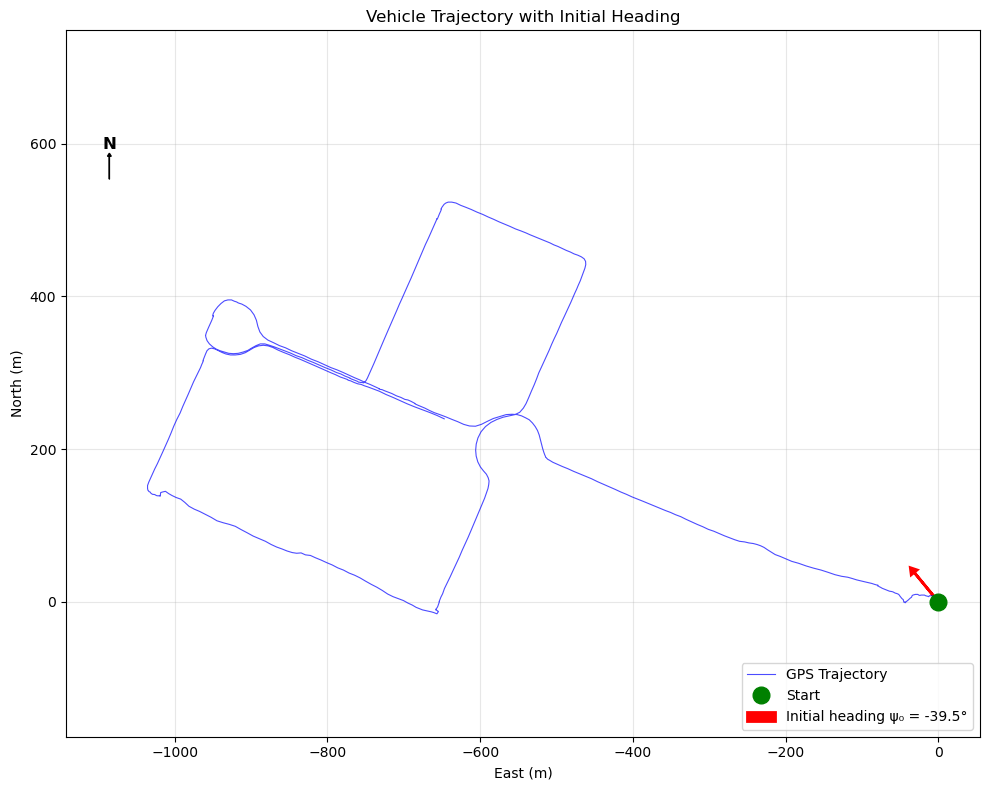


GPS-derived heading range: [-180.0°, 177.0°]
This can be used as validation for EKF heading estimation.

READY FOR EKF
Initial state values:
  p_x(0) = 0.00 m (East)
  p_y(0) = 0.00 m (North)
  ψ(0)   = -0.6885 rad (-39.45°)
  v(0)   = 1.82 m/s


In [12]:
# 5. Initial Heading Estimation & EKF Coordinate Convention
# ============================================================
# Convention: ENU-North (standard navigation convention)
#   - ψ = 0:     Vehicle pointing North (+Y direction)
#   - ψ = π/2:   Vehicle pointing East (+X direction)  
#   - ψ = π:     Vehicle pointing South (-Y direction)
#   - ψ = -π/2:  Vehicle pointing West (-X direction)
#   - Positive ψ: Counter-clockwise rotation when viewed from above
#
# Motion model (for EKF prediction):
#   ṗ_x = v * sin(ψ)   (East component)
#   ṗ_y = v * cos(ψ)   (North component)
#   ψ̇ = ω_z
# ============================================================

# Compute initial heading from first few GPS points
# Use points that are far enough apart to reduce GPS noise effect
n_skip = 10  # Skip first few points (may have noise while stationary)
n_avg = 20   # Use this many points for averaging

# Find a segment where the vehicle is actually moving
speed_threshold = 0.5  # m/s - ignore stationary periods
moving_mask = np.array([np.interp(t, time_vector_Vx, Vx) > speed_threshold 
                        for t in time_vector_long_x])
moving_indices = np.where(moving_mask)[0]

if len(moving_indices) > n_skip + n_avg:
    # Use GPS displacement during initial movement
    idx_start = moving_indices[n_skip]
    idx_end = moving_indices[n_skip + n_avg]
    
    dx = x_east[idx_end] - x_east[idx_start]
    dy = y_north[idx_end] - y_north[idx_start]
    
    # Initial heading: atan2(East, North) for ENU-North convention
    psi_0 = np.arctan2(dx, dy)
else:
    # Fallback: use first significant displacement
    dx = x_east[50] - x_east[0]
    dy = y_north[50] - y_north[0]
    psi_0 = np.arctan2(dx, dy)

print("="*60)
print("INITIAL HEADING ESTIMATION (ENU-North Convention)")
print("="*60)
print(f"Initial heading ψ₀ = {psi_0:.4f} rad = {np.rad2deg(psi_0):.2f}°")
print(f"  → 0° = North, 90° = East, ±180° = South, -90° = West")
print(f"Displacement used: Δx_east = {dx:.2f} m, Δy_north = {dy:.2f} m")

# Visualize initial heading on trajectory
plt.figure(figsize=(10, 8))
plt.plot(x_east, y_north, 'b-', linewidth=0.8, alpha=0.7, label='GPS Trajectory')
plt.plot(x_east[0], y_north[0], 'go', markersize=12, label='Start', zorder=5)

# Draw heading arrow at start position
arrow_length = 50  # meters
arrow_dx = arrow_length * np.sin(psi_0)  # East component
arrow_dy = arrow_length * np.cos(psi_0)  # North component
plt.arrow(x_east[0], y_north[0], arrow_dx, arrow_dy, 
          head_width=10, head_length=8, fc='red', ec='red', linewidth=2,
          label=f'Initial heading ψ₀ = {np.rad2deg(psi_0):.1f}°')

# Add compass reference
compass_x, compass_y = x_east.min() - 50, y_north.max() + 30
plt.annotate('N', xy=(compass_x, compass_y + 40), fontsize=12, ha='center', fontweight='bold')
plt.arrow(compass_x, compass_y, 0, 30, head_width=5, head_length=4, fc='black', ec='black')

plt.xlabel('East (m)')
plt.ylabel('North (m)')
plt.title('Vehicle Trajectory with Initial Heading')
plt.legend(loc='lower right')
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Compute heading from GPS at all points (for validation/comparison)
# This gives "ground truth" heading that EKF should track
psi_gps = np.zeros(len(x_east))
for i in range(1, len(x_east)):
    dx_i = x_east[i] - x_east[i-1]
    dy_i = y_north[i] - y_north[i-1]
    dist = np.sqrt(dx_i**2 + dy_i**2)
    if dist > 0.1:  # Only update if there's significant movement
        psi_gps[i] = np.arctan2(dx_i, dy_i)
    else:
        psi_gps[i] = psi_gps[i-1]  # Keep previous heading when stationary
psi_gps[0] = psi_0

print(f"\nGPS-derived heading range: [{np.rad2deg(psi_gps.min()):.1f}°, {np.rad2deg(psi_gps.max()):.1f}°]")
print(f"This can be used as validation for EKF heading estimation.")

# Store for EKF use
print("\n" + "="*60)
print("READY FOR EKF")
print("="*60)
print(f"Initial state values:")
print(f"  p_x(0) = {x_east[0]:.2f} m (East)")
print(f"  p_y(0) = {y_north[0]:.2f} m (North)")
print(f"  ψ(0)   = {psi_0:.4f} rad ({np.rad2deg(psi_0):.2f}°)")
print(f"  v(0)   = {Vx[0]:.2f} m/s")

SENSOR DATA SYNCHRONIZATION
Master timeline: 183937 samples from omega_z (200.0 Hz)
GPS measurements: 4599 points marked as available
GPS effective rate: 5.0 Hz
Average dt: 5.00 ms
dt range: [4.05, 6.39] ms


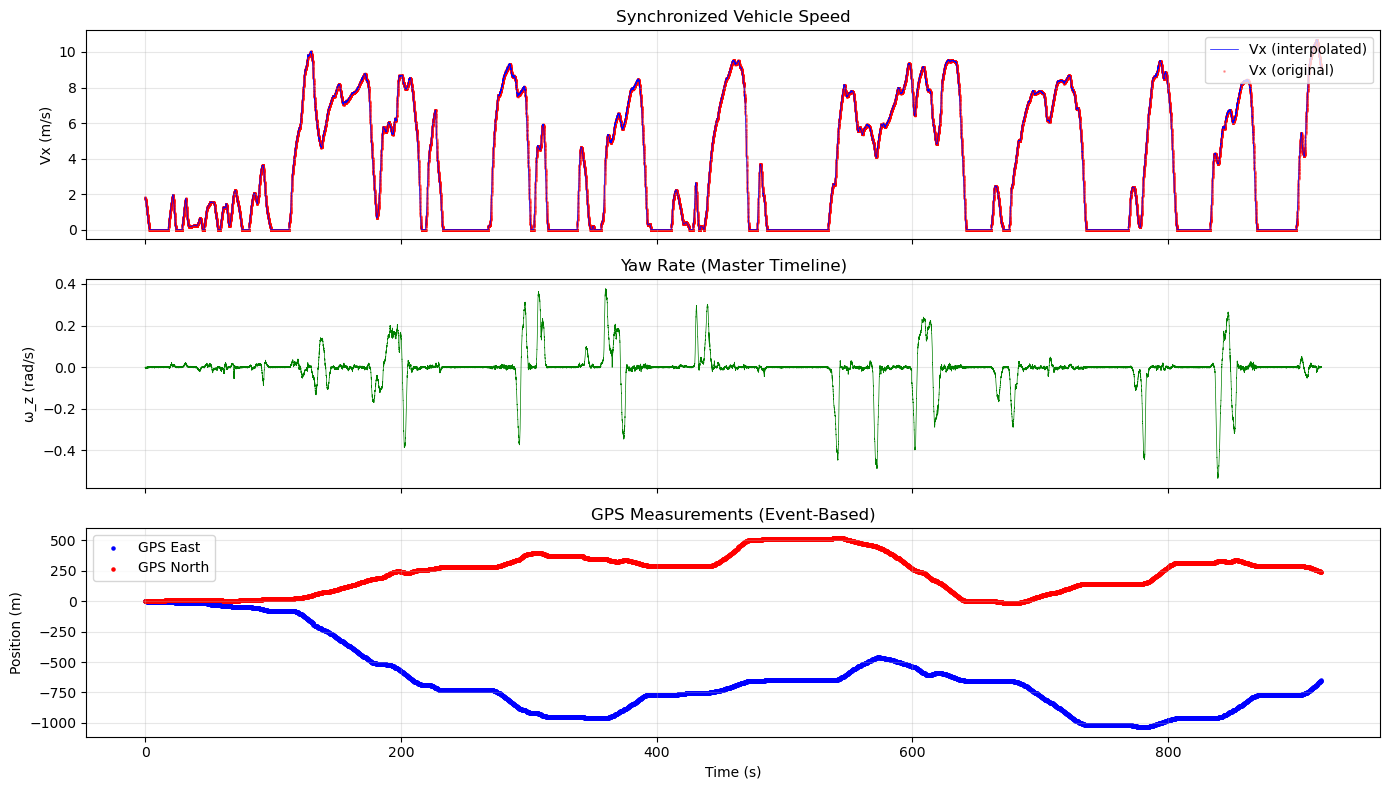


✓ Sensor data synchronized for event-driven EKF


In [13]:
# ============================================================================
# 6. SENSOR DATA SYNCHRONIZATION FOR EVENT-DRIVEN EKF
# ============================================================================
# Strategy: Build a master timeline at the highest frequency sensor (IMU/omega_z ~200Hz)
# - Prediction: At every IMU timestamp using interpolated Vx
# - GPS Update: Only at actual GPS timestamps (marked with availability flag)
# ============================================================================

from scipy.interpolate import interp1d

# Use omega_z timestamps as master timeline (highest frequency ~200 Hz)
master_time = time_vector_omega_z.copy()
N = len(master_time)

print("="*70)
print("SENSOR DATA SYNCHRONIZATION")
print("="*70)
print(f"Master timeline: {N} samples from omega_z ({1/np.mean(np.diff(master_time)):.1f} Hz)")

# Interpolate Vx to master timeline (needed continuously for prediction)
# Use linear interpolation - Vx changes slowly
Vx_interp_func = interp1d(time_vector_Vx, Vx, kind='linear', 
                          bounds_error=False, fill_value='extrapolate')
Vx_sync = Vx_interp_func(master_time)

# omega_z is already on master timeline
omega_z_sync = omega_z.copy()

# GPS: Find nearest master_time index for each GPS timestamp
# Mark availability - only update EKF when GPS is actually available
gps_available = np.zeros(N, dtype=bool)
px_gps_sync = np.full(N, np.nan)
py_gps_sync = np.full(N, np.nan)

# GPS time vector (use longitude time, same as latitude)
time_vector_gps = time_vector_long_x  

for i, t_gps in enumerate(time_vector_gps):
    # Find nearest master timeline index
    idx = np.argmin(np.abs(master_time - t_gps))
    # Only mark as available if within reasonable time tolerance (50 ms)
    if np.abs(master_time[idx] - t_gps) < 0.05:
        gps_available[idx] = True
        px_gps_sync[idx] = x_east[i]
        py_gps_sync[idx] = y_north[i]

print(f"GPS measurements: {np.sum(gps_available)} points marked as available")
print(f"GPS effective rate: {np.sum(gps_available) / (master_time[-1] - master_time[0]):.1f} Hz")

# Compute dt for each step
dt_sync = np.diff(master_time)
dt_sync = np.insert(dt_sync, 0, dt_sync[0])  # Prepend first dt for index alignment

print(f"Average dt: {np.mean(dt_sync)*1000:.2f} ms")
print(f"dt range: [{np.min(dt_sync)*1000:.2f}, {np.max(dt_sync)*1000:.2f}] ms")

# Verify synchronization with plot
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

ax1 = axes[0]
ax1.plot(master_time, Vx_sync, 'b-', linewidth=0.5, label='Vx (interpolated)')
ax1.scatter(time_vector_Vx, Vx, c='r', s=1, alpha=0.3, label='Vx (original)')
ax1.set_ylabel('Vx (m/s)')
ax1.legend(loc='upper right')
ax1.set_title('Synchronized Vehicle Speed')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(master_time, omega_z_sync, 'g-', linewidth=0.5)
ax2.set_ylabel('ω_z (rad/s)')
ax2.set_title('Yaw Rate (Master Timeline)')
ax2.grid(True, alpha=0.3)

ax3 = axes[2]
gps_idx = np.where(gps_available)[0]
ax3.scatter(master_time[gps_idx], px_gps_sync[gps_idx], c='b', s=5, label='GPS East')
ax3.scatter(master_time[gps_idx], py_gps_sync[gps_idx], c='r', s=5, label='GPS North')
ax3.set_ylabel('Position (m)')
ax3.set_xlabel('Time (s)')
ax3.set_title('GPS Measurements (Event-Based)')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Sensor data synchronized for event-driven EKF")

In [14]:
# checking th elength of the synchronized arrays
print(f"Length of master_time: {len(master_time)}")
print(f"Length of Vx_sync: {len(Vx_sync)}")
print(f"Length of omega_z_sync: {len(omega_z_sync)}")
print(f"Length of gps_available: {len(gps_available)}")
print(f"Length of px_gps_sync: {len(px_gps_sync)}")
print(f"Length of py_gps_sync: {len(py_gps_sync)}")

Length of master_time: 183937
Length of Vx_sync: 183937
Length of omega_z_sync: 183937
Length of gps_available: 183937
Length of px_gps_sync: 183937
Length of py_gps_sync: 183937


In [15]:
# Synchronized data looks fine to make a dictionary to store the synchronized signals for EKF use
synchronized_signals = {
    "master_time": master_time,
    "Vx_sync": Vx_sync,
    "omega_z_sync": omega_z_sync,
    "gps_available": gps_available,
    "px_gps_sync": px_gps_sync,
    "py_gps_sync": py_gps_sync
}

# Convert NumPy arrays to lists
synchronized_signals_serializable = {
    key: value.tolist() if isinstance(value, np.ndarray) else value
    for key, value in synchronized_signals.items()
}

# Save the synchronized signals to a .json file for EKF use (optional)
import json
with open("synchronized_signals.json", "w") as f:
    json.dump(synchronized_signals_serializable, f, indent=4)        # indent=4 for human readable formatting

In [16]:
state = np.array([px_gps_sync, py_gps_sync, omega_z_sync]).T
control = np.array([Vx_sync, omega_z_sync]).T
np.shape(state), np.shape(control)

((183937, 3), (183937, 2))